In [9]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
from sklearn.svm import SVC
from itertools import product
from sklearn.base import clone
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
from scipy.stats import randint, uniform
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.base import clone
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

# Multi-Model Random Search – Explained Steps :

## 1. **Load Train & Test Data**

* Read `train.csv`(Which is the combination of Train & validation dataset after deduplication) and `test.csv` using pandas.
* These already have features and a label column (e.g., `"protein_name"`).

## 2. **Encode Labels**

* Convert `protein_name` (text labels) into numeric labels using `LabelEncoder`.
* This is required because machine learning models need numbers, not strings.

## 3. **Prepare Features and Labels**

* Remove unnecessary columns like:

  * `uniprot_id` and `protein_name` (identifiers)
  * `label_column` (temporarily moved to `y`)
* Split the data into:

  * `X_train`, `y_train` for training
  * `X_test`, `y_test` for testing

## 4. **Define Models**

* Set up 2 classifiers:

  * `RandomForestClassifier`
  * `AdaBoostClassifier`

## 5. **Define Hyperparameter Search Space**

* Create a different set of hyperparameter options for each model.
* Use `randint` and `uniform` to generate random values within a range.
* These will be sampled during random search.

## 6. **Run Randomized Search**

* For each model:

  * Perform `RandomizedSearchCV` with:

    * The model
    * Its parameter space
    * `n_iter` (how many random combos to try)
    * Cross-validation (`cv`)
    * Scoring metric (`accuracy`)
  * Train it and evaluate on test set.
  * Print accuracy and classification report.

## 7. **Store Results**

* Save the best model, accuracy, parameters, and full report for each model.
* Use a dictionary called `self.results`.

## 8. **Select the Best Model**

* Pick the model with the highest test accuracy.
* Save it as `self.best_model` and its name.

## 9. **Get the Best Model**

* Use `get_best_model()` to return the top model and its name for later use (e.g., saving or inference).

In [2]:
class MultiModelRandomSearch:
    def __init__(self, train_df: pd.DataFrame, test_df: pd.DataFrame, label_column: str):
        self.label_column = label_column

        self.label_encoder = LabelEncoder()
        train_df[label_column] = self.label_encoder.fit_transform(train_df[label_column])
        test_df[label_column] = self.label_encoder.transform(test_df[label_column])

        drop_cols = [label_column, "uniprot_id", "protein_name", "fold"]
        self.X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
        self.y_train = train_df[label_column]

        self.X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])
        self.y_test = test_df[label_column]

        self.models = {
            "RandomForest": RandomForestClassifier(random_state=42),
            "AdaBoost": AdaBoostClassifier(random_state=42)
        }

        self.param_distributions = {
            "RandomForest": {
                "n_estimators": randint(100, 300),
                "max_depth": [None, 10, 20, 30],
                "min_samples_split": randint(2, 10),
                "min_samples_leaf": randint(1, 5),
                "bootstrap": [True, False]
            },
            "AdaBoost": {
                "n_estimators": randint(50, 150),
                "learning_rate": uniform(0.1, 1.0)
            }
        }

        self.results = dict()
        self.best_model = None
        self.best_model_name = ""

    def run_random_search(self, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1):
        for name, model in self.models.items():
            print(f"\nRunning RandomizedSearchCV for {name}...")

            random_search = RandomizedSearchCV(
                estimator=model,
                param_distributions=self.param_distributions[name],
                n_iter=n_iter,
                cv=cv,
                scoring=scoring,
                n_jobs=n_jobs,
                random_state=42,
                verbose=1
            )

            random_search.fit(self.X_train, self.y_train)

            best_model = random_search.best_estimator_
            best_params = random_search.best_params_
            y_pred = best_model.predict(self.X_test)
            acc = accuracy_score(self.y_test, y_pred)

            print(f"{name} - Accuracy: {acc:.4f}")
            print(f"Best Params: {best_params}")
            print("\nClassification Report:\n", classification_report(self.y_test, y_pred))

            self.results[name] = {
                "model": best_model,
                "accuracy": acc,
                "params": best_params,
                "report": classification_report(self.y_test, y_pred, output_dict=True)
            }

        self.best_model_name = max(self.results, key=lambda k: self.results[k]["accuracy"])
        self.best_model = self.results[self.best_model_name]["model"]

        print(f"\nBest Model: {self.best_model_name} with accuracy {self.results[self.best_model_name]['accuracy']:.4f}")

    def get_best_model(self):
        return self.best_model, self.best_model_name

if __name__ == "__main__":
    train_df = pd.read_csv("../processed_data/Split data/train_dd.csv")
    val_df = pd.read_csv("../processed_data/Split data/val_dd.csv")
    test_df = pd.read_csv("../processed_data/Split data/test_dd.csv")

    combined_train_df = pd.concat([train_df, val_df], ignore_index=True)

    selector = MultiModelRandomSearch(
        train_df=combined_train_df,
        test_df=test_df,
        label_column="protein_name"
    )

    selector.run_random_search(n_iter=25)
    best_model, name = selector.get_best_model()


Running RandomizedSearchCV for RandomForest...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
RandomForest - Accuracy: 0.7913
Best Params: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 257}

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       0.67      0.05      0.09        40
           2       0.87      0.98      0.92        46
           3       0.58      0.96      0.72        56
           4       1.00      0.79      0.88        29
           5       1.00      0.96      0.98        23

    accuracy                           0.79       230
   macro avg       0.85      0.79      0.76       230
weighted avg       0.81      0.79      0.74       230


Running RandomizedSearchCV for AdaBoost...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
AdaBoost - Accuracy: 0.6957
Best Params: {'learning_rate': 0.82

# Final Model Evaluation

## 1. **Load Everything**

* Read the full processed dataset (`processed_protein_features.csv`).
* Get the best model, Random Forest (already trained) from the previous random search.

## 2. **Set Up Evaluator**

* Create `FinalModelEvaluator` with:

  * The best model
  * The full dataset
  * Label column name (`protein_name`)
  * Number of folds for cross-validation (`n_splits=5`)

## 3. **Prepare Data**

* Split the data into:

  * `X`: All features
  * `y`: The label column
* Set up `KFold` for splitting into `n_splits` folds with shuffling.

## 4. **Run Cross-Validation**

For each fold:

* Train the model on training part.
* Predict on validation part.
* Generate Confusion Matrix.
* Calculate and store:

  * Accuracy
  * Precision
  * Recall
  * F1-score
  * ROC AUC

## 5. **Print Final Results**

* For each metric:

  * Print **mean ± std** across all folds.



Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Confusion Matrix for Fold 5:
[[78  0  5  0  0  0]
 [ 0  1  0 40  0  0]
 [ 1  0 86  0  0  0]
 [ 0 31  4 36  0  0]
 [ 0  0  7  0 44  0]
 [ 0  0  1  0  0 52]]


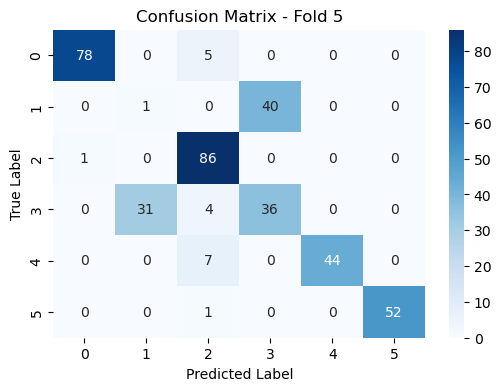


Cross-Validation Results:
Accuracy: 0.7658 ± 0.0143
Precision: 0.7541 ± 0.0227
Recall: 0.7658 ± 0.0143
F1: 0.7558 ± 0.0183
Roc_auc: 0.9301 ± 0.0075


In [10]:
class FinalModelEvaluator:
    def __init__(self, model, full_df: pd.DataFrame, label_column: str, n_splits: int = 5):
        self.model = model
        self.data = full_df
        self.label_column = label_column
        self.n_splits = n_splits

        drop_cols = [label_column, "uniprot_id", "protein_name"]
        self.X = self.data.drop(columns=[col for col in drop_cols if col in self.data.columns])
        self.y = self.data[label_column]

        if self.y.dtype == "object":
            from sklearn.preprocessing import LabelEncoder
            self.label_encoder = LabelEncoder()
            self.y = pd.Series(self.label_encoder.fit_transform(self.y), index=self.data.index)
        else:
            self.label_encoder = None

        self.kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=42)


    def evaluate(self, average='weighted'):
        metrics = {
            "accuracy": [],
            "precision": [],
            "recall": [],
            "f1": [],
            "roc_auc": []
        }

        for fold, (train_idx, val_idx) in enumerate(self.kf.split(self.X)):
            print(f"\nFold {fold + 1}")
            X_train, X_val = self.X.iloc[train_idx], self.X.iloc[val_idx]
            y_train, y_val = self.y.iloc[train_idx], self.y.iloc[val_idx]

            self.model.fit(X_train, y_train)
            y_pred = self.model.predict(X_val)

            metrics["accuracy"].append(accuracy_score(y_val, y_pred))
            metrics["precision"].append(precision_score(y_val, y_pred, average=average, zero_division=0))
            metrics["recall"].append(recall_score(y_val, y_pred, average=average, zero_division=0))
            metrics["f1"].append(f1_score(y_val, y_pred, average=average, zero_division=0))

            try:
                if hasattr(self.model, "predict_proba"):
                    y_proba = self.model.predict_proba(X_val)
                    if len(np.unique(y_val)) == 2:
                        metrics["roc_auc"].append(roc_auc_score(y_val, y_proba[:, 1]))
                    else:
                        metrics["roc_auc"].append(roc_auc_score(y_val, y_proba, multi_class='ovr'))
                else:
                    metrics["roc_auc"].append(np.nan)
            except:
                metrics["roc_auc"].append(np.nan)
            
     # Confusion matrix calculation
        cm = confusion_matrix(y_val, y_pred)
        print(f"\nConfusion Matrix for Fold {fold + 1}:\n{cm}")

        # Plot confusion matrix heatmap
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - Fold {fold + 1}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()
            
        print("\nCross-Validation Results:")
        for metric, scores in metrics.items():
            valid_scores = [s for s in scores if not np.isnan(s)]
            mean_score = np.mean(valid_scores)
            std_score = np.std(valid_scores)
            print(f"{metric.capitalize()}: {mean_score:.4f} ± {std_score:.4f}")

        return metrics

if __name__ == "__main__":
    full_df = pd.read_csv("../processed_data/protein_features/processed_protein_features.csv")
    best_model, model_name = selector.get_best_model()

    evaluator = FinalModelEvaluator(
        model=best_model,
        full_df=full_df,
        label_column="protein_name",
        n_splits=5
    )

    metrics = evaluator.evaluate()



# PCA + KFold Model Evaluation – Step-by-Step Guide

## Class: `PCAKFoldEvaluator`

### What it does:

* Reduces feature dimensions using **PCA**.
* Finds the **best number of components**.
* Evaluates a model using **K-Fold cross-validation** on PCA-reduced data.


## `find_best_n_components()`

* Tries different PCA dimensions (every 5 components).
* For each `n_components`:

  * Applies PCA to the data.
  * Runs K-Fold CV with the model.
  * Calculates **mean accuracy**.
* Prints accuracy per PCA size.
* Returns the **number of components with the best CV accuracy**.

---

## `final_evaluation(n_components)`

* Runs a final K-Fold evaluation using the **best PCA dimension**.
* Calculates and prints:

  * Accuracy
  * Precision
  * Recall
  * F1-score
* Returns dictionary of metric scores


 Finding best PCA components using K-Fold...


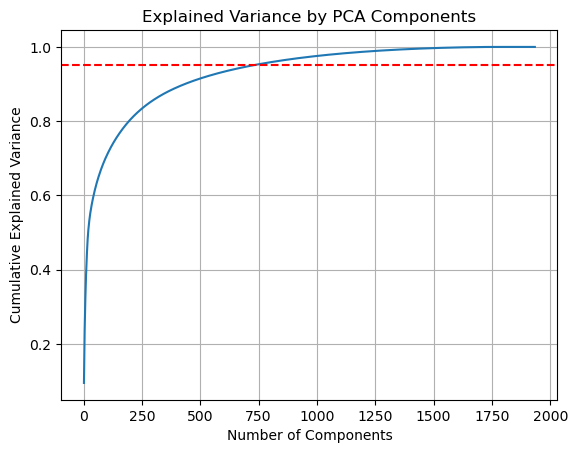

PCA Components: 200 → CV Accuracy: 0.7218
PCA Components: 400 → CV Accuracy: 0.7172
PCA Components: 600 → CV Accuracy: 0.7110
Early stopping: score dropped significantly.

Best PCA components: 200 with CV accuracy: 0.7218

Final Evaluation with 200 PCA components using K-Fold...

Cross-Validation Metrics:
Accuracy: 0.7213 ± 0.0079
Precision: 0.7003 ± 0.0127
Recall: 0.7213 ± 0.0079
F1: 0.7065 ± 0.0111


In [5]:
class PCAKFoldEvaluator:
    def __init__(self, model, full_df: pd.DataFrame, label_column: str, max_components: int = None, n_splits: int = 5):
        self.model = model
        self.label_column = label_column
        self.n_splits = n_splits

        drop_cols = ["uniprot_id", "protein_name", self.label_column]
        self.X = full_df.drop(columns=[col for col in drop_cols if col in full_df.columns])
        self.y = full_df[label_column]

        if self.y.dtype == 'object':
            self.label_encoder = LabelEncoder()
            self.y = pd.Series(self.label_encoder.fit_transform(self.y), index=full_df.index)
        else:
            self.label_encoder = None

        self.max_components = max_components if max_components else min(self.X.shape)
        self.kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    def find_best_n_components(self, step=5, early_stop_threshold=0.001, plot_variance=True):
        print(" Finding best PCA components using K-Fold...")

        pca_full = PCA(n_components=self.max_components)
        X_full_pca = pca_full.fit_transform(self.X)

        best_score = 0
        best_n = 0

        if plot_variance:
            explained = np.cumsum(pca_full.explained_variance_ratio_)
            plt.plot(range(1, len(explained) + 1), explained)
            plt.axhline(y=0.95, color='r', linestyle='--')
            plt.title("Explained Variance by PCA Components")
            plt.xlabel("Number of Components")
            plt.ylabel("Cumulative Explained Variance")
            plt.grid(True)
            plt.show()

        for n in range(step, self.max_components + 1, step):
            X_pca = X_full_pca[:, :n]
            scores = cross_val_score(clone(self.model), X_pca, self.y, cv=self.kf, scoring="accuracy", n_jobs=-1)
            mean_score = np.mean(scores)
            print(f"PCA Components: {n} → CV Accuracy: {mean_score:.4f}")

            if mean_score > best_score + early_stop_threshold:
                best_score = mean_score
                best_n = n
            elif best_score - mean_score > 0.01:
                print("Early stopping: score dropped significantly.")
                break

        print(f"\nBest PCA components: {best_n} with CV accuracy: {best_score:.4f}")
        return best_n

    def final_evaluation(self, n_components):
        print(f"\nFinal Evaluation with {n_components} PCA components using K-Fold...")

        pca = PCA(n_components=n_components)
        X_pca = pca.fit_transform(self.X)

        metrics = {
            "accuracy": [],
            "precision": [],
            "recall": [],
            "f1": []
        }

        for fold, (train_idx, val_idx) in enumerate(self.kf.split(X_pca)):
            X_train, X_val = X_pca[train_idx], X_pca[val_idx]
            y_train, y_val = self.y[train_idx], self.y[val_idx]

            model = clone(self.model)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            metrics["accuracy"].append(accuracy_score(y_val, y_pred))
            metrics["precision"].append(precision_score(y_val, y_pred, average='weighted', zero_division=0))
            metrics["recall"].append(recall_score(y_val, y_pred, average='weighted', zero_division=0))
            metrics["f1"].append(f1_score(y_val, y_pred, average='weighted', zero_division=0))

        print("\nCross-Validation Metrics:")
        for metric, scores in metrics.items():
            print(f"{metric.capitalize()}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

        return metrics


if __name__ == "__main__":
    import joblib

    full_df = pd.read_csv("../processed_data/protein_features/processed_protein_features.csv")
    best_model, model_name = selector.get_best_model()

    evaluator = PCAKFoldEvaluator(
        model=best_model,
        full_df=full_df,
        label_column="protein_name",
        n_splits=5
    )

    best_n = evaluator.find_best_n_components(step=200)
    final_metrics = evaluator.final_evaluation(n_components=best_n)

